### Regression
1) It is a predictive modeling technique which investigates the relationship between dependent and independent variables(one or more) <br>
2) Dependent variable is continuous in nature eg - Sales, Weight, Profit, Revenue, Price,Distance, Magintude,Height, Weight etc<br>

3) <pre>
   y = depenedent varaible/output/target variable
   x = independent variable/input(s)
   </pre>

Features = Attributes = Variables = Dimensions = Columns (for Tabular data)

### Simple Linear Regression
1) It is a regression model that estimates the relationship between one independent variable and one dependent variable using a straight line.<br>
2) It has an equation of the form <b> y = mx + c</b><br>

Where-<br>
x = independent variable/ input feature/input attribute<br>
y = dependent variable / output feature/target attribute<br>
m = slope or coefficient or how much we expect y to change as x changes       
c = intercept / constant <br>

In this graph, x = Time spent Studying, y = Marks obtained. The orange dots are the corresponding data points. The blue line is the best fit line for Linear regression(y = mx +c)

<img src="reg1.png">

### Best Fit Line
The Linear Regression model finds the best fit line that minimizes the squared error between the actual data points and its perpendicular dropped on the predicted line.<br>

SST = Total Sum of Squares <br>
SSE = Error Sum of squares <br>
SSR = Regression sum of squares<br>

<img src="reg2.png">

<img src="reg3.png">

In [ ]:
# SSE = variance between actual data point and its correspoding predicted value
# SSR = variance between predicted value and mean of target variable
# SST = Total Variation
# SST = SSE + SSR

### R2 score (Coefficient of Determination) - Goodness of fit

The coefficient of determination is the portion of the total variation in the dependent variable that is explained by variation in the independent variable

<img src="reg4.png">

<b>SST = SSE + SSR</b><br>
R2 score  = SSR/SST = (SST- SSE)/ SST = 1 – SSE/SST<br>
When SSE= 0, R2 score = 1 (Best case scenario) <br>
and when SSE = SST, R2 score = 0(not desirable)<br>


#### Can R2 be negative
1) R2 = 1 - (SSE/SST)<br>
2) R2 will be negative when SSE/SST  > 1 => when SSE > SST<br>
3) R2 will be negative when ypred < ymean<br>

### Regression Metrics

<img src="reg5.png">

### Multiple Linear Regression

1)	Multiple linear regression is used to estimate the relationship between two or more independent variables and one dependent variable. <br>

2)	It has an equation of the form <b>y = m1x1 + m2x2 + m3x3 +…..+ mnxn + c </b><br>
where:-<br>
x1,x2,x3,...,xn = independent variables/ input features<br>
y = dependent variable / output feature<br>
m1,m2,m3...,mn = coefficients/slope  corresponding to x1 - xn             
c = intercept / constant <br>

In [ ]:
# ML Model
# 1) Definition , learning type - supervused or unsup
# 2) Application
# 3) Evalutaion/Performance Metrics
# 4) Hyperparameters of Model
# 5) Cost Function and its optmization - OLS
# 6) Pros and Cons

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Simple Linear Regression


In [1]:
x = [20,30,25,17,36,40,46,55,52,27,50,33,42,21,48,37,23,33,14,19,52]    
y = [41,63,51,39,78,75,87,98,102,60,101,70,86,47,90,69,58,64,41,47,98]  

print(len(x),len(y))

# x = independent feature
# y = dependent feature
# y = mx + c

21 21


In [4]:
df = pd.DataFrame({'x':x,'y':y})
df.head()

,x,y
0,20,41
1,30,63
2,25,51
3,17,39
4,36,78


In [5]:
df.shape  # rows = 21, cols = 2

(21, 2)

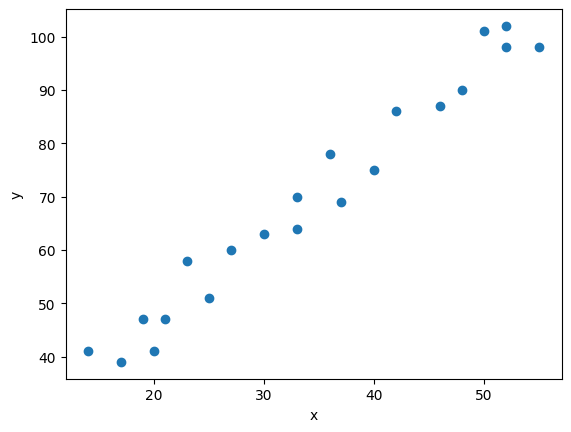

In [6]:
plt.scatter(df['x'],df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#### Problem Statement - Generate the regression model relating y(dependent variable) and x(independent variable)

### Equation : y = mx + c

Q) Create a function <br>
a) To generate prediction values for x using the equation y = mx + c where m and c are arguments. Plot the data points, along with Regression line. Create a column called y_pred<br>
b) Create a Column SSE(Error sum of square) and SAE(Sum of  Absolute Errors), SSR, SST<br>
c) Compute MSE, RSME and MAE<br>
d) Compute R2 as well<br>

In [ ]:
# SSE = sum((yi - ypredi)^2)
# SSR = sum((ypredi - y_mean)^2)
# SST = SSE + SSR
# R2 = SSR/SST = 1 - (SSE/SST)
# MSE  = (1/n)* sum((yi - ypredi)^2) = (1/n)*SSE
# RMSE = sqrt(MSE)
# MAE = (1/n)*sum(|yi-ypredi|)
# ypred = mx + c

#### Regression Evaluation Metrics

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
def reg_model(data,m,c): # data is the dataframe df
    data['ypred'] = m*data['x']  + c
    mae = mean_absolute_error(data['y'], data['ypred'])
    mse = mean_squared_error(data['y'], data['ypred'])
    rmse = np.sqrt(mse)
    r2 = r2_score(data['y'], data['ypred'])
    print('MAE',mae,'MSE',mse,'RMSE',rmse)
    print('R2 Score',r2)
    plt.scatter(df['x'],df['y'],label='Actual Data')
    plt.plot(df['x'],df['ypred'],label='Predicted Line',color='maroon')
    plt.title(f'Reg Line y = {m}*x + {c}')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()
    return data

MAE 109.66666666666667 MSE 13871.57142857143 RMSE 117.77763551953075
R2 Score -31.447001601833094


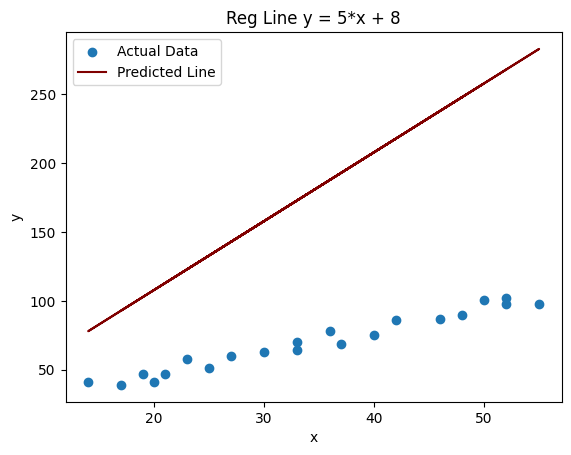

,x,y,ypred
0,20,41,108
1,30,63,158
2,25,51,133
3,17,39,93
4,36,78,188
5,40,75,208
6,46,87,238
7,55,98,283
8,52,102,268
9,27,60,143


In [10]:
reg_model(df,5,8)  # m = 5, c= 8

MAE 5.238095238095238 MSE 42.19047619047619 RMSE 6.495419631592418
R2 Score 0.9013122301547731


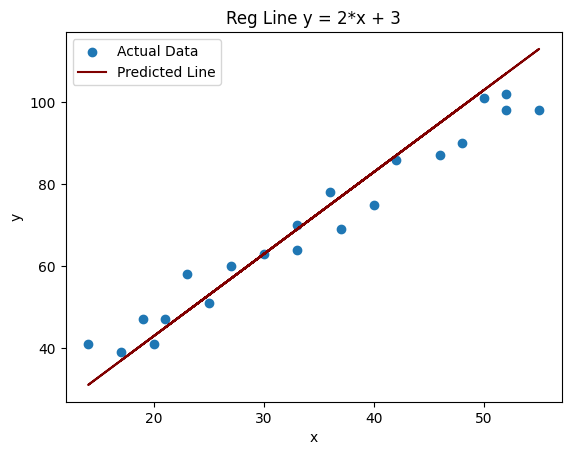

,x,y,ypred
0,20,41,43
1,30,63,63
2,25,51,53
3,17,39,37
4,36,78,75
5,40,75,83
6,46,87,95
7,55,98,113
8,52,102,107
9,27,60,57


In [11]:
reg_model(df,2,3)  # m=2,c=3

MAE 5.095238095238095 MSE 39.57142857142857 RMSE 6.29058253037257
R2 Score 0.9074384461158199


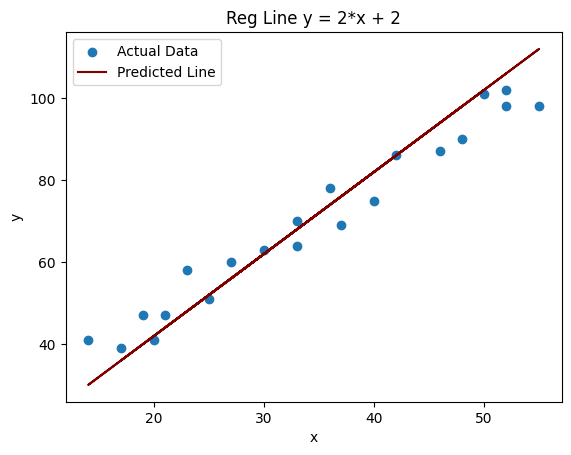

,x,y,ypred
0,20,41,42
1,30,63,62
2,25,51,52
3,17,39,36
4,36,78,74
5,40,75,82
6,46,87,94
7,55,98,112
8,52,102,106
9,27,60,56


In [12]:
reg_model(df,2,2)

MAE 14.833333333333334 MSE 236.6547619047619 RMSE 15.383587419869329
R2 Score 0.4464406950470472


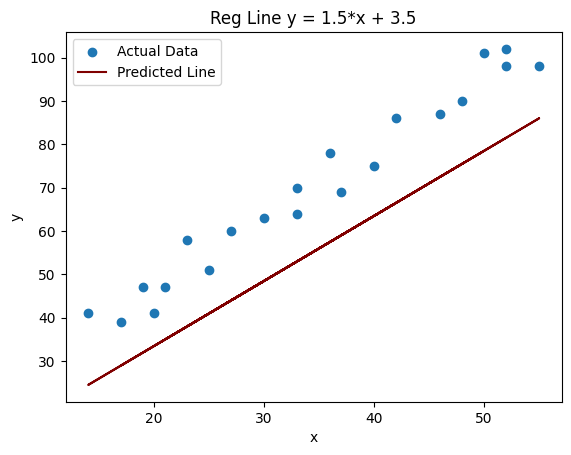

,x,y,ypred
0,20,41,33.5
1,30,63,48.5
2,25,51,41.0
3,17,39,29.0
4,36,78,57.5
5,40,75,63.5
6,46,87,72.5
7,55,98,86.0
8,52,102,81.5
9,27,60,44.0


In [13]:
reg_model(df,1.5,3.5)

#### Linear Regression using Library

In [16]:
#### 1) Select x and y
x = df[['x']]  # 2D array - dataframe
y = df['y']    # 1D array - Series
print(x.shape)
print(y.shape)

(21, 1)
(21,)


In [17]:
#### Import the library - Linear Regression
from sklearn.linear_model import LinearRegression

In [18]:
# Model Training
model = LinearRegression()    # model is an instance/object of LinearRegression
model.fit(x,y)                # model will be trained on x and y

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# Generate Predictions
ypred = model.predict(x)    # generate predictions for x
print(len(ypred))

21


In [21]:
## Evaluate the Model
mae = mean_absolute_error(y,ypred)
mse = mean_squared_error(y,ypred)
rmse = np.sqrt(mse)
r2 = r2_score(y,ypred)
print('MAE',mae,'MSE',mse,'RMSE',rmse)
print('R2 Score',r2)

MAE 3.3830095672043563 MSE 14.698691374599107 RMSE 3.833887240725672
R2 Score 0.9656182816033277


In [22]:
#### Extract m and c
m = model.coef_
c = model.intercept_
print('Slope',m)
print('Constant',c)

Slope [1.61003845]
Constant 14.560586643884356


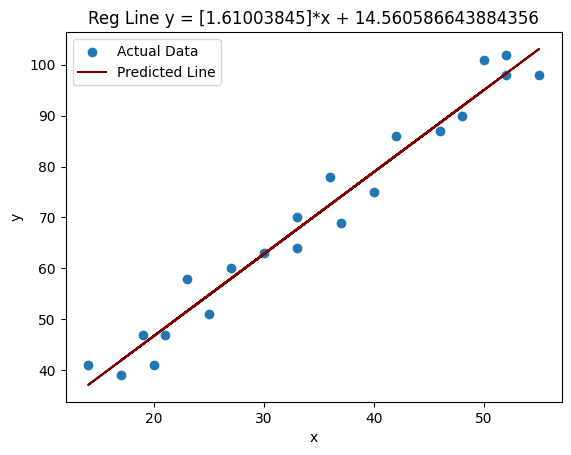

In [23]:
# Visualization
plt.scatter(df['x'],df['y'],label='Actual Data')
plt.plot(df['x'],ypred,label='Predicted Line',color='maroon')
plt.title(f'Reg Line y = {m}*x + {c}')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

MAE 3.383009583042111 MSE 14.698691374599123 RMSE 3.8338872407256743
R2 Score 0.9656182816033277


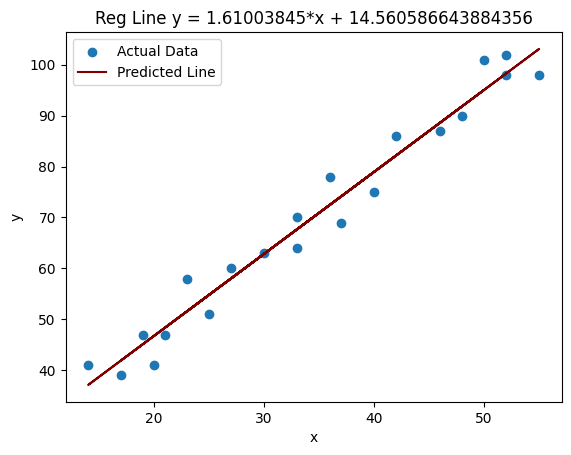

,x,y,ypred
0,20,41,46.761356
1,30,63,62.861740
2,25,51,54.811548
3,17,39,41.931240
4,36,78,72.521971
5,40,75,78.962125
6,46,87,88.622355
7,55,98,103.112701
8,52,102,98.282586
9,27,60,58.031625


In [24]:
reg_model(df,1.61003845, 14.560586643884356)

In [53]:
#### Generate Predictions for
# x = 25
# x = 35.5

In [25]:
x1 = 25
x2 = 35.5

In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
# ypred = mx + c
ypred_x1 = m*x1 + c
print(ypred_x1)
print(model.predict([[x1]]))


[54.81154777]
[54.81154777]


In [28]:
ypred_x2 = m*x2 + c
print(ypred_x2)
print(model.predict([[x2]]))

[71.71695145]
[71.71695145]


#### Assumptions of Linear Regression

1) <b>No Null Values</b>

2) <b>No/Minimal outliers</b>

3) <b>No Multicollinearity </b>

<b>Multicollinearity</b> - Independent features haveing high correlation tend to have high Multicollinearity
Ex : Car_Manf_Yr and Car_Age

<b>How to detect</b> - Check correlation, Check VIF
VIF -  Variance Inflation Factor

<b>Solution</b> - Features with high VIF can be dropped.

4) <b>Homoscedasticity</b> -
 <b>Homoscedasticity</b> - Errors should have constant variance.
 If we plot predicted values(x-axis) and errors(y-axis), the scatter chart should have constant nature.

#### Q) How does Linear Regression model find m and c ?

Premise - Linear Regression find the best fit line where MSE is minimum



#### OLS - Ordinary Least Square

1) It finds the best model parameters (m and c) such that the MSE is minimum
2) OLS also helps in feature selection.

<pre>
ypred = mx + c
MSE = (1/n)*sum((yi - ypredi)^2), i varies from 1 to n
MSE = (1/n)*sum((yi - (m*xi + c))^2)
Error = Loss = Cost = (1/n)*sum((yi - (m*xi + c))^2)

Objective : Minimize MSE
a) 
Partial derivative of Loss wrt m = dLoss/dm
Partial derivative of Loss wrt c = dLoss/dc

b) Equate it with 0 
dLoss/dm = 0
dLoss/dc = 0



#### Implementation of OLS

In [29]:
import statsmodels.api as sm

In [30]:
X = x.copy()
Y = y.copy()

In [36]:
X = sm.add_constant(X)     # ols model generates the intercept/constant (c) => Y = mX + C
ols = sm.OLS(Y,X).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     533.6
Date:                Sun, 08 Feb 2026   Prob (F-statistic):           2.28e-15
Time:                        19:25:34   Log-Likelihood:                -58.019
No. Observations:                  21   AIC:                             120.0
Df Residuals:                      19   BIC:                             122.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.5606      2.546      5.718      0.0

In [32]:
m = model.coef_
c = model.intercept_
print('Slope',m)
print('Constant',c)

Slope [1.61003845]
Constant 14.560586643884356


In [34]:
print(ols.params)

const    14.560587
x         1.610038
dtype: float64


#### Adjusted R2

1) R2 = Proportion of total variation in the dependent variable that can be explained by the variation in the indepdennt variables/(s).
2) R2 = SSR/STT = 1 - (SSE/SST)
3) It tends to increases or stays same on addition or more features.
4) Adjusted R2<pre>
   a) It penalizes R2 aon addition of more features.
   b) If additional features are truly significant, then Adj R2 will increase
   c) If additional features are  insignificant, then Adj R2 will decrease.
   d) It will be always less than equal to R2.
   e) Definition - Proportion of total variation in the dependent variable that can be explained by the variation in only truly significant features indepdennt variables/(s). (features that are acutally contributing towards  prediction of target variable)

#### Example

Simple numeric example (very important)

Assume:

100 observations

Target: Sales

Model 1: One meaningful predictor

Sales ~ Advertising Spend

R² = 0.70

Adjusted R² = 0.697

➡ Good model, strong signal

Model 2: Add a useless variable

Sales ~ Advertising Spend + Employee ID

R² = 0.71 ⬆️

Adjusted R² = 0.695 ⬇️

What happened?

R² increased just because we added a variable

Adjusted R² penalized the useless feature

👉 This is exactly why Adjusted R² matters.

Model 3: Add a useful variable

Sales ~ Advertising Spend + Discount Rate

R² = 0.78

Adjusted R² = 0.775

➡ Both increased → feature actually helps

#### Role of p-value in Linear Regression

<pre>
Ho : The feature/predictor has coef = 0  => Feature is not significant
H1 : The feature/predictor has coef != 0 => Feature is Significant

alpha = 0.05
If p > alpha => Ho accepted => Feature is not significant
If p <= alpha => H1 accepted => Feature is Significant

#### Overfitting
1) When the model performs too well on the training data but compartaively poorly on the test data. This is called overfitting.<br>
Example:<br>
a) Train R2 = 0.92, Test R2 = 0.78<br>
b) Train RMSE = 1038, Test RMSE = 1549

#### Underfitting
1) When the model performs too well on the testing data but compartaively poorly on the train data. This is called underfitting.<br>
Example:<br>
a) Train R2 = 0.83, Test R2 = 0.90


#### Regularization

1) It is method/mechanism to treat overfitting.
2) Cost Function of Linear Regression
3) Cost = MSE = (1/n)*sum((yi-ypredi)^2)) = for Linear Reg
ypred = mx + c

#### Types of Regularization

1) <b>Ridge(L2 Regularization</b><br>
a) In Ridge Regression, we add a penalty term to the Cost Function of Linear Regression <br>
b) Cost = MSE + alpha*sum(m^2), alpha = Regularization coefficient<br>
c) Ridge shrinks the coefficients<br>


3) <b>Lasso (L1 Regularization)</b><br>
a) In Ridge Regression, we add a penalty term to the Cost Function of Linear Regression <br>
b) Cost = MSE + alpha*sum(|m|),  alpha = Regularization coefficient<br>
c) Ridge shrinks the coefficients to such an extent that it becomes 0. So Lasso is used for Feature Selection
